In [2]:
from default_libs import *

In [3]:
df=pd.read_csv(r"C:\Users\lette\Data Analytics\Data Visualization\Zomato-data-.csv")

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [7]:
df.rename(columns={'approx_cost(for two people)':'cost for 2 people','listed_in(type)':'restaurant type'},inplace=True)

In [8]:
def rate_clean(points):
    points=str(points).split('/')
    points=points[0]
    return float(points)

df['rate']=df['rate'].apply(rate_clean)
df.head()

,name,online_order,book_table,rate,votes,cost for 2 people,restaurant type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# Column Pairs

1. Numerical vs Numerical
2. Numerical vs Categorical
3. Categorical vs Numerical
4. Categorical vs Categorical


## Nummerical vs Numerical Pair

## Scatter plot

In [6]:
# Sctter plot reveal the following:

# is linearity in the data ?
# is clusters ?
# is outliers ?
# spread ?
# is hidden segments ?

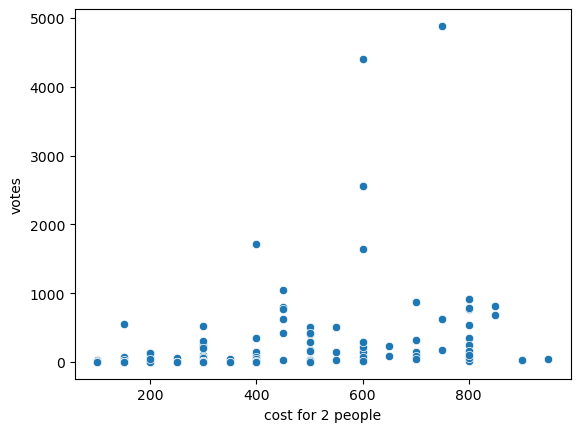

In [7]:
sns.scatterplot(x=df['cost for 2 people'], y=df['votes'])
plt.show()

### Adding Trend Line

In [8]:
# trendline shows direction easily

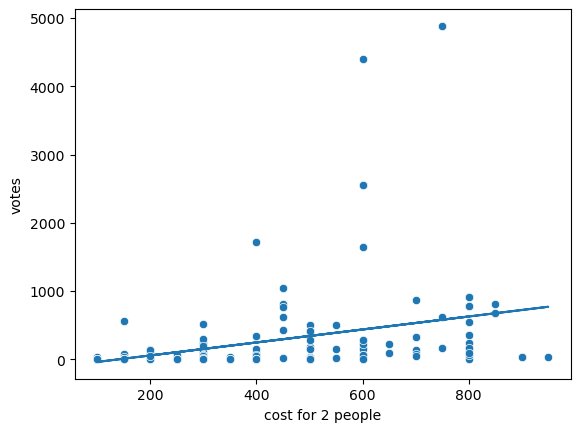

In [9]:
sns.scatterplot(x=df['cost for 2 people'], y=df['votes'])
a=np.polyfit(df['cost for 2 people'],df['votes'],1)
b=np.poly1d(a)
plt.plot(df['cost for 2 people'],b(df['cost for 2 people']))
plt.savefig('cost vs votes zomato with trendline.jpg')
plt.show()

## Heatmap

In [10]:
# heatmap reveals the following:

# correlation among pairs
# detects redandancy (duplicates)
# identifyies multi-collinearity

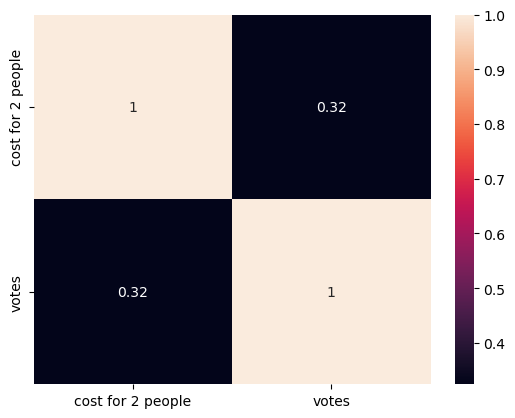

In [11]:
selected_colomns=['cost for 2 people','votes']
df_subset=df[selected_colomns]
correlation_matrix=df_subset.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()

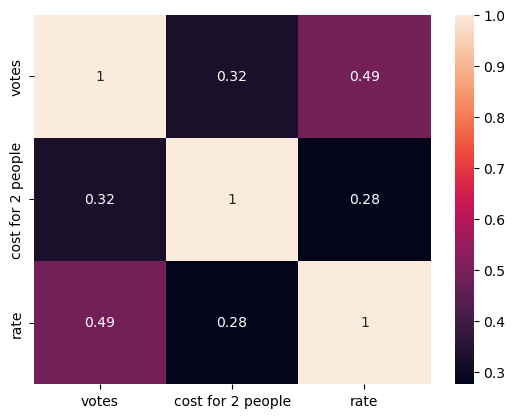

In [12]:
main_columns=['votes','cost for 2 people', "rate"]
subset_data=df[main_columns]
dataset_correlation=subset_data.corr()
sns.heatmap(dataset_correlation, annot=True)
plt.show()

### Heatmap - interpretation

In [13]:
# it measures only correlation, nothing else

# 1 is high correlation , 0 is NO correlation

# if any 2 features show 0.85+ correlation , they carry same information. it causes multi-collinearity

## Numerical vs Categorical pair

### Box plot

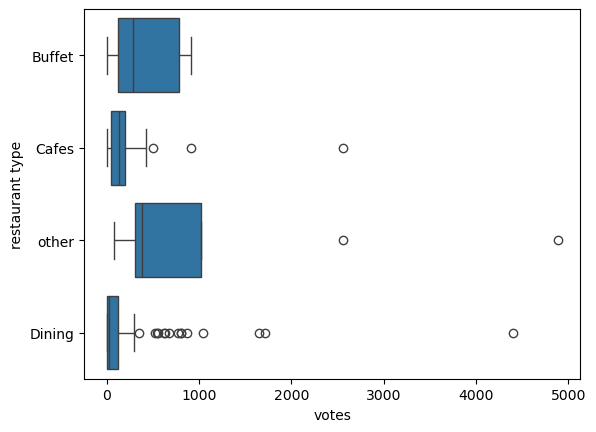

In [14]:
sns.boxplot(x=df['votes'],y=df['restaurant type'])
plt.show()

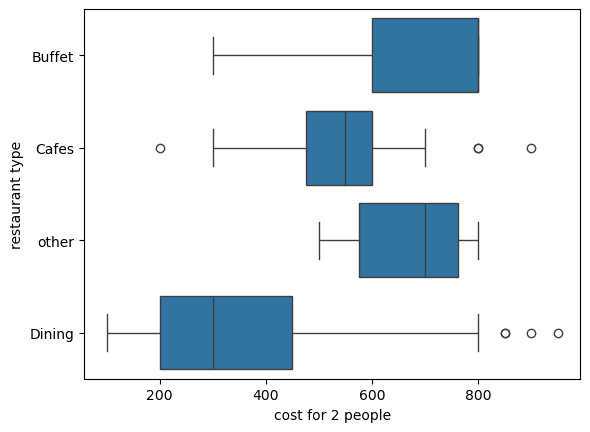

In [15]:
sns.boxplot(x=df['cost for 2 people'],y=df['restaurant type'])
plt.show()

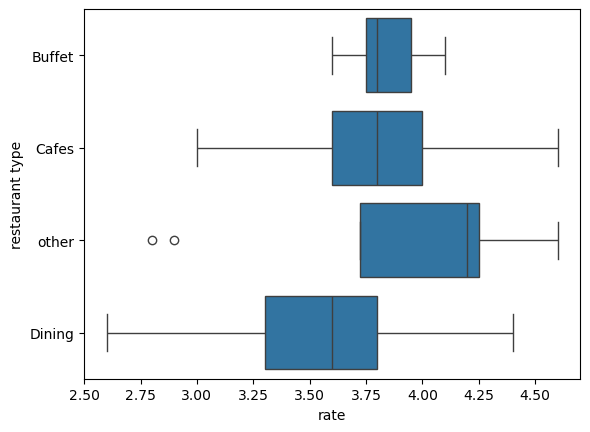

In [16]:
sns.boxplot(x=df['rate'],y=df['restaurant type'])
plt.show()

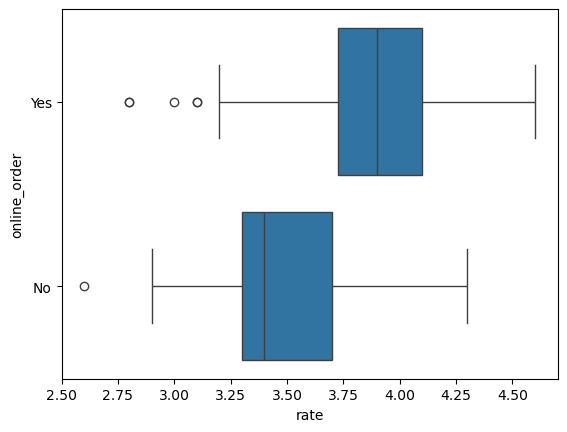

In [17]:
sns.boxplot(x=df['rate'],y=df['online_order'])
plt.show()

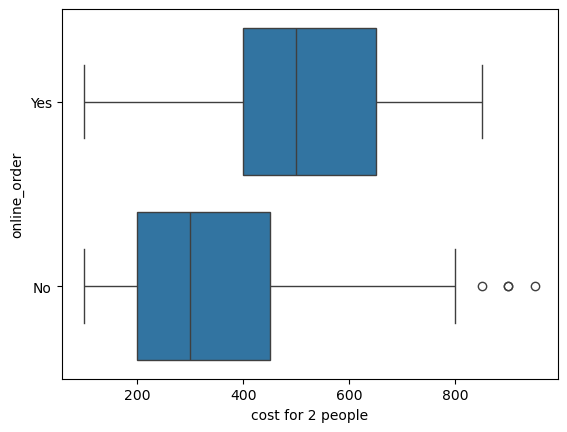

In [18]:
sns.boxplot(x=df['cost for 2 people'],y=df['online_order'])
plt.show()

## Categorical vs Categorical Pair

### With Counts

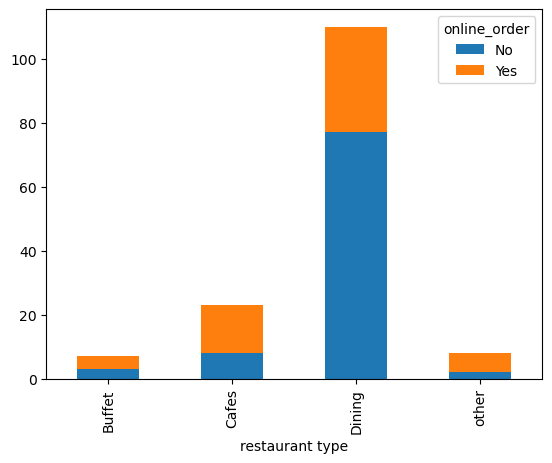

In [19]:
cross_tab=pd.crosstab(df['restaurant type'],df['online_order'])
cross_tab.plot(kind='bar', stacked=True)
plt.show()

### With Percentages

In [21]:
# Percentages are used when propertions matter more than counts 

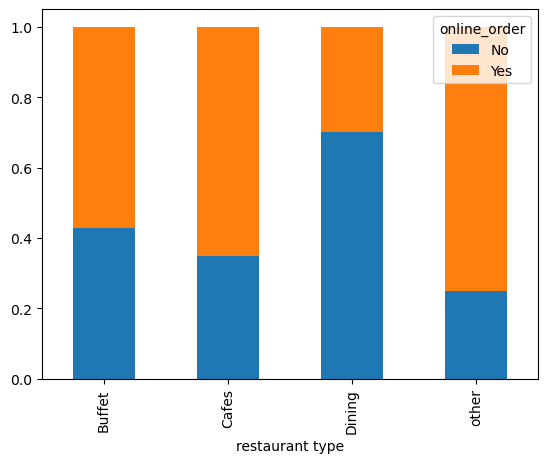

In [22]:
cross_tab=pd.crosstab(df['restaurant type'],df['online_order'], normalize='index')
cross_tab.plot(kind='bar', stacked=True)
plt.show()